# Постановка задачи

Ваша задача — создать и обучить нейросеть, которая будет предсказывать калорийность блюд. Полученную модель можно интегрировать во многие fitness и health-приложения, она будет полезна тем, кто следит за своим здоровьем. 

![Без масок](./docs/calories_illustration.png)

**Цель**
Получить DL-модель, способную оценить калорийность блюда

**Целевая метрика**
Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке. 

**Датасет**
Вы поработаете с датасетом (1.3 ГБ): https://disk.yandex.ru/d/kz9g5msVqtahiw, который содержит фотографии блюд, описание ингредиентов, а также общую массу порции и калорийность.
- data/ingredients.csv
    - id — ID ингредиента.
    - ingr — название ингредиента.
- data/dish.csv
    - dish_id — ID блюда.
    - total_calories — общее число калорий. Это целевая переменная.
    - total_mass — масса блюда.
    - ingredients — список всех ID ингредиентов в формате ingr_0000000122;ingr_0000000026;.., где ненулевая часть соответствует ID ингредиента из data/ingredients.csv.
    - split — метка, указывающая, куда отнести блюдо: train/test. Эта метка поможет разделить датасет при тренировке.
- data/images — датасет с фотографиями блюд, каждая директория соответствует dish_id из data/dish.csv и содержит rgb.png фото блюда.

# Настройка окружения

In [1]:
from pathlib import Path

In [2]:
class Config:
    SEED = 42

    # Параметры массы для нормализации (взяты из анализа)
    MASS_MEAN = 214.980
    MASS_STD = 161.497
    MASS_USE_LOG = True  # (max-min)=3050 при mean=215 - необходимо сделать распределение более симметричным

    # Параметры массы для нормализации (взяты из анализа)
    CAL_MEAN = 255.013
    CAL_STD = 219.638
    CAL_USE_LOG = True  # (max-min)=3943 при mean=255 - необходимо сделать распределение более симметричным

    # Модели
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "resnet50"

    # Какие слои размораживаем - совпадают с неймингом в моделях
    TEXT_MODEL_UNFREEZE = "encoder.layer.9|encoder.layer.10|encoder.layer.11|pooler"
    IMAGE_MODEL_UNFREEZE = "layer4.|conv_head|bn2"
    
    # Гиперпараметры
    BATCH_SIZE = 32
    TEXT_LR = 3e-5      #  LR для текстовой модели
    IMAGE_LR = 1e-4     #  LR для изображений
    MLP_LR = 5e-4       #  LR для классификатора
    EPOCHS = 100
    DROPOUT = 0.15
    HIDDEN_DIM = 256 # размерность проекции признаков моделей

    # Пути
    BASE_DIR = Path.cwd()
    DATASET_DIR = BASE_DIR / "data"
    IMAGES_DIR = DATASET_DIR / "images"
    DISH_CSV_PATH = DATASET_DIR / "dish.csv"
    INGREDIENTS_CSV_PATH = DATASET_DIR / "ingredients.csv"
    WEIGHTS_DIR = BASE_DIR / "models" / "calories_normalized"

config = Config()
print("Dataset directory:", config.DATASET_DIR)

Dataset directory: /home/evgeniy/Документы/GitHub/Multimodal-model--Calories-Calculator/data


# Этап 1. Анализ данных (EDA)

In [3]:
import os
import re
import random

import pandas as pd
import matplotlib.pyplot as plt

## Данные о блюдах

In [6]:
dish_df = pd.read_csv(config.DISH_CSV_PATH, encoding='utf-8')

print(f"Количество строк: {len(dish_df)}")
print(f"Количество столбцов: {len(dish_df.columns)}")

dish_df.head()

Количество строк: 3262
Количество столбцов: 5


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [7]:
dish_df.describe()


,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


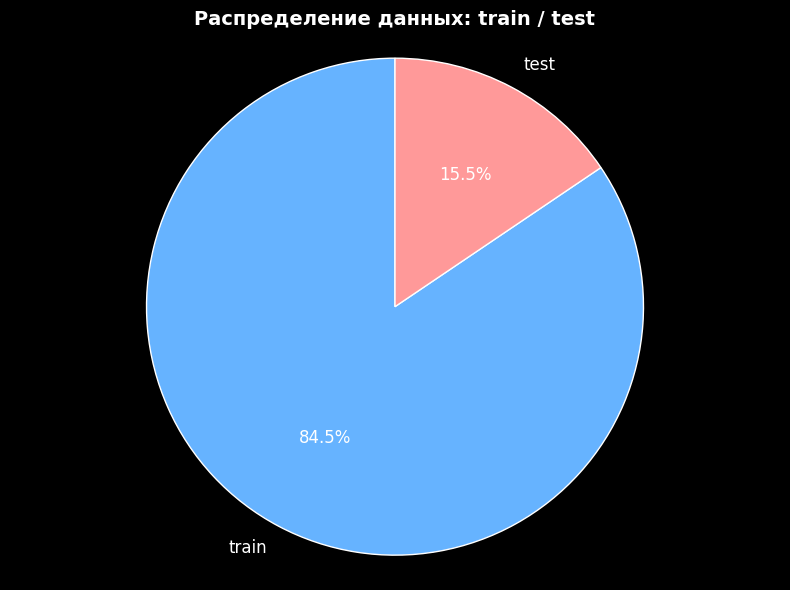

In [8]:
# Test/train
split_counts = dish_df['split'].value_counts(dropna=False)
plt.figure(figsize=(8, 6))
plt.pie(
    split_counts.values, 
    labels=split_counts.index.astype(str),  # преобразуем в строку для корректного отображения NaN
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999', '#cccccc'],  # цвета для train, test, NaN
    textprops={'fontsize': 12}
)
plt.title('Распределение данных: train / test', fontsize=14, fontweight='bold')
plt.axis('equal')  # равные пропорции для круга
plt.tight_layout()
plt.show()

In [9]:
# Общая статистика пропусков
missing = dish_df.isnull().sum()
missing_pct = (missing / len(dish_df) * 100).round(2)

print("🔴 Пропущенные значения по столбцам:")
missing_summary = pd.DataFrame({
    'Пропуски': missing,
    '% от общего': missing_pct
}).query('Пропуски > 0').sort_values('% от общего', ascending=False)

if not missing_summary.empty:
    print(missing_summary.to_string())
else:
    print("  ✅ Пропущенных значений не обнаружено")

🔴 Пропущенные значения по столбцам:
  ✅ Пропущенных значений не обнаружено


In [10]:
def find_anomalies():
    anomalies = {}
    
    # ── dish_id: проверка на дубликаты и пустые строки ──
    if 'dish_id' in dish_df.columns:
        dupes = dish_df['dish_id'].duplicated().sum()
        empty = dish_df['dish_id'].astype(str).str.strip().eq('').sum()
        if dupes > 0 or empty > 0:
            anomalies['dish_id'] = f"дубликаты: {dupes}, пустые: {empty}"
        print(f"  • dish_id: {len(dish_df['dish_id'].unique())} уникальных из {len(dish_df)}")
    
    # ── total_calories: числовой, должен быть >= 0 ──
    if 'total_calories' in dish_df.columns:
        col = dish_df['total_calories']
        neg = (col < 0).sum() if pd.api.types.is_numeric_dtype(col) else 0
        nan = col.isnull().sum()
        # Подозрительно высокие значения (> 10000 ккал?)
        suspicious_high = (col > 10000).sum() if pd.api.types.is_numeric_dtype(col) else 0
        if neg > 0 or suspicious_high > 0:
            anomalies['total_calories'] = f"отрицательные: {neg}, подозрительно высокие: {suspicious_high}"
        print(f"  • total_calories: мин={col.min():.2f}, макс={col.max():.2f}, сред={col.mean():.2f}")
    
    # ── total_mass: числовой, должен быть >= 0 ──
    if 'total_mass' in dish_df.columns:
        col = dish_df['total_mass']
        neg = (col < 0).sum() if pd.api.types.is_numeric_dtype(col) else 0
        suspicious_high = (col > 5000).sum() if pd.api.types.is_numeric_dtype(col) else 0  # >5 кг?
        if neg > 0 or suspicious_high > 0:
            anomalies['total_mass'] = f"отрицательные: {neg}, подозрительно высокие: {suspicious_high}"
        print(f"  • total_mass: мин={col.min():.2f}, макс={col.max():.2f}, сред={col.mean():.2f}")
    
    # ── split: проверка на допустимые значения ──
    if 'split' in dish_df.columns:
        expected = {'train', 'test'}
        actual = set(dish_df['split'].dropna().astype(str).str.lower().str.strip())
        invalid = actual - expected
        if invalid:
            anomalies['split'] = f"недопустимые значения: {invalid}"
            # Показать примеры
            invalid_mask = ~dish_df['split'].astype(str).str.lower().str.strip().isin(expected)
            print(f"  ⚠️ Примеры некорректных split: {dish_df.loc[invalid_mask, 'split'].unique()[:5]}")
        else:
            print(f"  • split: значения корректны ({dish_df['split'].value_counts().to_dict()})")
            
    # ── ingredients: проверка на пустые строки и странные символы ──
    if 'ingredients' in dish_df.columns:
        print("🔎 Анализ столбца 'ingredients':")
        
        # 1. Пропуски и пустые значения
        missing = dish_df['ingredients'].isnull().sum()
        empty = (dish_df['ingredients'].astype(str).str.strip().eq('')).sum() - missing
        print(f"  • Пропущено (NaN): {missing}, Пустые строки: {empty}")
        
        # 2. Статистика по количеству ингредиентов
        def count_ingredients(val):
            if pd.isna(val) or str(val).strip() == '':
                return 0
            return str(val).strip().count(';') + 1
        
        ingr_counts = dish_df['ingredients'].apply(count_ingredients)
        print(f"  • Ингредиентов: мин={ingr_counts[ingr_counts>0].min()}, "
              f"макс={ingr_counts.max()}, среднее={ingr_counts[ingr_counts>0].mean():.1f}")
        
        # 3. Проверка формата (валидация паттерна)
        valid_pattern = r'^(ingr_\d{10})(;ingr_\d{10})*$'
        invalid_mask = dish_df['ingredients'].apply(
            lambda x: not bool(re.match(valid_pattern, str(x).strip())) if pd.notna(x) and str(x).strip() else False
        )
        invalid_count = invalid_mask.sum()
        
        if invalid_count > 0:
            print(f"\n  ⚠️  Найдено {invalid_count} записей с некорректным форматом:")
            print(dish_df.loc[invalid_mask, 'ingredients'].head(5).to_string())
        else:
            print(f"  • Все значения соответствуют формату 'ingr_XXXXXXXXXX'")
    return anomalies

In [11]:
print("\n🔎 Поиск аномалий по столбцам:")
anomalies = find_anomalies()
print(f"\n{'⚠️ Обнаружены аномалии:' if anomalies else '✅ Аномалий не обнаружено'}")
for col, desc in anomalies.items():
    print(f"  • {col}: {desc}")


🔎 Поиск аномалий по столбцам:
  • dish_id: 3262 уникальных из 3262
  • total_calories: мин=0.00, макс=3943.33, сред=255.01
  • total_mass: мин=1.00, макс=3051.00, сред=214.98
  • split: значения корректны ({'train': 2755, 'test': 507})
🔎 Анализ столбца 'ingredients':
  • Пропущено (NaN): 0, Пустые строки: 0
  • Ингредиентов: мин=1, макс=34, среднее=7.3
  • Все значения соответствуют формату 'ingr_XXXXXXXXXX'

✅ Аномалий не обнаружено


## Данные об ингредиентах

In [12]:
ingredients_df = pd.read_csv(config.INGREDIENTS_CSV_PATH, encoding='utf-8')
print(f"Количество строк: {len(ingredients_df)}")
print(f"Количество столбцов: {len(ingredients_df.columns)}")
ingredients_df.head()

Количество строк: 555
Количество столбцов: 2


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [13]:
# Общая статистика пропусков
missing = dish_df.isnull().sum()
missing_pct = (missing / len(dish_df) * 100).round(2)

print("🔴 Пропущенные значения по столбцам:")
missing_summary = pd.DataFrame({
    'Пропуски': missing,
    '% от общего': missing_pct
}).query('Пропуски > 0').sort_values('% от общего', ascending=False)

if not missing_summary.empty:
    print(missing_summary.to_string())
else:
    print("  ✅ Пропущенных значений не обнаружено")

🔴 Пропущенные значения по столбцам:
  ✅ Пропущенных значений не обнаружено


## Изображения

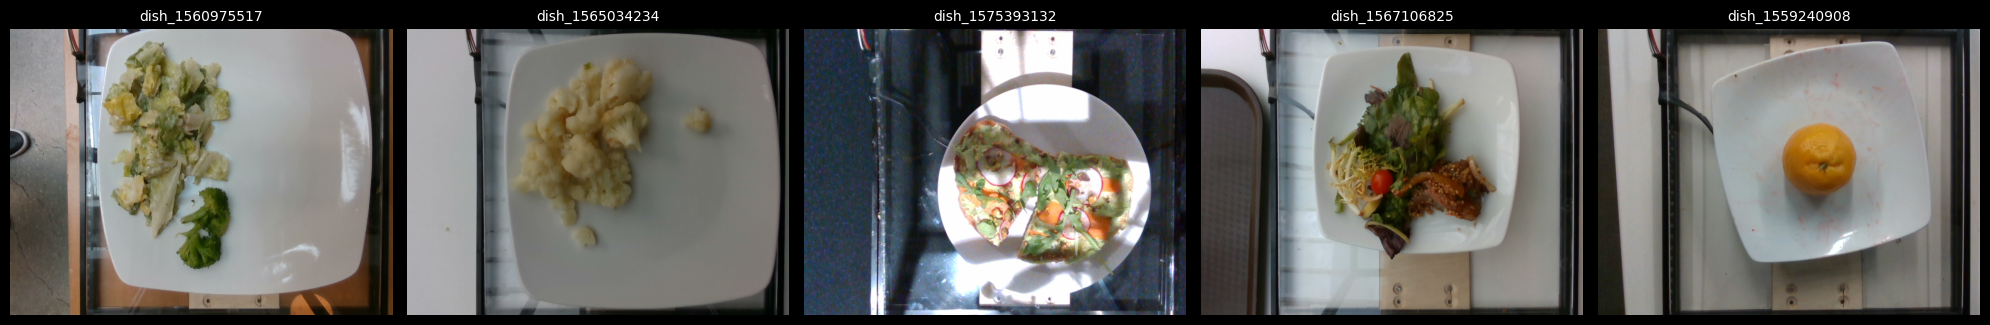

In [14]:
# Получаем список всех папок
images_folders = [f for f in os.listdir(config.IMAGES_DIR) 
                  if os.path.isdir(os.path.join(config.IMAGES_DIR, f))]

# Выбираем 5 случайных папок
selected_folders = random.sample(images_folders, min(5, len(images_folders)))
images_size = None

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, folder in enumerate(selected_folders):
    folder_path = config.IMAGES_DIR / folder
    image_path = folder_path / f"rgb.png"
    img = plt.imread(image_path)
    images_size = img.shape
    axes[idx].imshow(img)
    axes[idx].set_title(f"{folder}", fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [15]:
print("Images size:", images_size)

Images size: (480, 640, 3)


In [16]:
images_folders = set(images_folders)
dish_ids = set(dish_df['dish_id'].astype(str).unique())

print(f"✅ Полное совпадение: {len(images_folders.intersection(dish_ids))}")
print(f"⚠️ Папки без dish_id: {len(images_folders - dish_ids)}")
print(f"⚠️ dish_id без папок: {len(dish_ids - images_folders)}")

images_without_real_id = list(images_folders - dish_ids)
id_without_images = list(dish_ids - images_folders)
print(f"\nПримеры несовпадений (папки): {images_without_real_id[:5]}")
print(f"Примеры несовпадений (dish_id): {id_without_images[:5]}")

✅ Полное совпадение: 3262
⚠️ Папки без dish_id: 228
⚠️ dish_id без папок: 0

Примеры несовпадений (папки): ['dish_1573666680', 'dish_1571931482', 'dish_1572376754', 'dish_1572031254', 'dish_1574097565']
Примеры несовпадений (dish_id): []


## Анализ данных

**Общие выводы:**
- Все данные корректны, выбросов нет, исправления не нужны.
- Пропусков в данных нет.
- Некоторым изображениям не соответствуют никакие id из таблицы блюд (всего 228/3262). Они никогда не будут использованы в обучении и их можно исключить для экономии ресурсов.
- Разбиение на обучающую и тестовую выборку в отношении: 84.5% / 15.5%. Выделим столько же данных на валидацию, сколько выделено на тест, из обучающих данных.
- Размер изображений (480, 640, 3).
- Поскольку названия ингредиентов не представляют собой единый текст, но при этом имеют свой вклад в калорийность, они не будут объединяться в текст, но для получения весов значимости каждого из ингредиентов будет использован attention между эмбедингами каждого ингредиента.
- Разброс калорий и массы весьма существенный, поэтому будет добавлена нормализация причём с предварительным применением log(1 + x) для смещения распределения ближе к симметричному.

**Аугментации:**
- Изображения (фотографирует пользователь, поэтому могут отличаться ракурсы съёмки и цветовая передача)
    - Rotation
    - Flip (горизонтальный/вертикальный)
    - Scaling/Zoom
    - Сдвиг (Translation)
    - Perspective transform
    - Brightness adjustment
    - Contrast adjustment
    - Saturation
    - Hue shift
    - Blur
    - Sharpening
- Текст (предполагаем, что ингредиенты вводит пользователь, поэтому могут быть опечатки)
    - Keyboard Noise
    - Character Swap

**Ключевые метрики:**
- MAE < 50 - на train и val
- MAPE (Mean Absolute Percentage Error) - распределение каллорий от 0 до ~4000 со средним 255, поэтому интересно посмотреть на относительную ошибку

# Этап 2. Пайплайн обучения

## Загрузка данных

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from functools import partial
from transformers import AutoTokenizer

from src.dataset import CaloriesDataset, get_text_transforms, get_image_transforms, collate_fn

In [4]:
dish_df = pd.read_csv(config.DISH_CSV_PATH, encoding='utf-8')

### Разбиение на train, test, val

In [5]:
# val - 15% от общих данных, также как тест 
val_count = len(dish_df[dish_df["split"] == "test"])
train_count = len(dish_df[dish_df["split"] == "train"]) - val_count

dish_train_val_df = dish_df[dish_df["split"] == "train"]
dish_df_train, dish_df_val = train_test_split(
    dish_train_val_df, 
    train_size=train_count, 
    test_size=val_count,
    random_state=42,
    shuffle=True
)

# Сброс индекса для быстрого доступа по iloc
dish_train_df = dish_df_train.reset_index(drop=True)
dish_val_df = dish_df_val.reset_index(drop=True)
dish_test_df = dish_df[dish_df["split"] == "test"].reset_index(drop=True)
print("train:", len(dish_train_df))
print("val:", len(dish_val_df))
print("test:", len(dish_test_df))

train: 2248
val: 507
test: 507


### Аугментации

In [6]:
train_image_transform = get_image_transforms(config, "train")
val_image_transform = get_image_transforms(config, "val")
test_image_transform = get_image_transforms(config, "test")

train_text_transform = get_text_transforms("train")
val_text_transform = get_text_transforms("val")
test_text_transform = get_text_transforms("test")

### Datasets & Dataloaders

In [7]:
train_dataset = CaloriesDataset(dish_train_df, 
                                config, 
                                train_image_transform, 
                                train_text_transform)

val_dataset = CaloriesDataset(dish_val_df, 
                              config, 
                              val_image_transform, 
                              val_text_transform)

test_dataset = CaloriesDataset(dish_test_df, 
                               config, 
                               test_image_transform, 
                               test_text_transform)

In [8]:
# Пример элемента CaloriesDataset
sample = train_dataset[1]

print(f"Тип: {type(sample)}")
print(f"Ключи: {sample.keys()}")
print(f"\nСодержимое:")
for key, value in sample.items():
    if hasattr(value, 'shape'):
        print(f"{key}: тензор {value.shape}, dtype={value.dtype}")
    elif isinstance(value, list):
        print(f"{key}: список из {len(value)} элементов: {value}")
    else:
        print(f"{key}: {type(value)} = {value}")

Тип: <class 'dict'>
Ключи: dict_keys(['mass', 'image', 'ingr_list', 'target'])

Содержимое:
mass: тензор (), dtype=float64
image: тензор torch.Size([3, 224, 224]), dtype=torch.float32
ingr_list: список из 17 элементов: ['soy sauce', 'white rice', 'ginger', 'squash', 'olive oil', 'garlic', 'green onions', 'cheese pizaz', 'broccoli', 'caesar salad', 'pineapple', 'chicken', 'spinach (raw)', 'green beans', 'vinegar', 'zucchini', 'salt']
target: тензор (), dtype=float64


In [9]:
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)

In [10]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(collate_fn, tokenizer=tokenizer),
    num_workers=4
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer),
    num_workers=4
)

test_dataset = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer),
    num_workers=4
)

In [11]:
sample = next(iter(val_dataloader))
print("Tokenized ingredients:", sample["ingrs"].shape)
print("Mask for tokenized ingredients:", sample["attention_mask"].shape)
print("Images:", sample["image"].shape)
print("Masses:", sample["mass"].shape)
print("Calories:", sample["target"].shape)

Tokenized ingredients: torch.Size([32, 26, 7])
Mask for tokenized ingredients: torch.Size([32, 26, 7])
Images: torch.Size([32, 3, 224, 224])
Masses: torch.Size([32])
Calories: torch.Size([32])


## Модель

In [3]:
from torchinfo import summary
import torch

from src.utils import set_requires_grad
from src.model import CaloriesModel

In [7]:
model = CaloriesModel(config)

set_requires_grad(model.text_model, unfreeze_pattern=config.TEXT_MODEL_UNFREEZE, verbose=True)
set_requires_grad(model.image_model, unfreeze_pattern=config.IMAGE_MODEL_UNFREEZE, verbose=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Разморожен слой: encoder.layer.9.attention.self.query.weight
Разморожен слой: encoder.layer.9.attention.self.query.bias
Разморожен слой: encoder.layer.9.attention.self.key.weight
Разморожен слой: encoder.layer.9.attention.self.key.bias
Разморожен слой: encoder.layer.9.attention.self.value.weight
Разморожен слой: encoder.layer.9.attention.self.value.bias
Разморожен слой: encoder.layer.9.attention.output.dense.weight
Разморожен слой: encoder.layer.9.attention.output.dense.bias
Разморожен слой: encoder.layer.9.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.9.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.9.intermediate.dense.weight
Разморожен слой: encoder.layer.9.intermediate.dense.bias
Разморожен слой: encoder.layer.9.output.dense.weight
Разморожен слой: encoder.layer.9.output.dense.bias
Разморожен слой: encoder.layer.9.output.LayerNorm.weight
Разморожен слой: encoder.layer.9.output.LayerNorm.bias
Разморожен слой: encoder.layer.10.attention.self.query.w

In [8]:
# Описание модели
dummy_input = [
    torch.randint(0, 1000, (config.BATCH_SIZE, 20, 8)).long(),   # ingrs
    torch.ones((config.BATCH_SIZE, 20, 8)).long(),               # attention_mask
    torch.randn((config.BATCH_SIZE, 3, 224, 224)),               # image
    torch.randn((config.BATCH_SIZE,))                            # mass
]

summary(
    model,
    input_data=dummy_input,  # Передаём готовые тензоры вместо кортежей
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=5,
    verbose=1
)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
CaloriesModel                                           [32, 20, 8]               [32]                      --                        Partial
├─BertModel: 1-1                                        [640, 8]                  [640, 768]                --                        Partial
│    └─BertEmbeddings: 2-1                              --                        [640, 8, 768]             --                        False
│    │    └─Embedding: 3-1                              [640, 8]                  [640, 8, 768]             (23,440,896)              False
│    │    └─Embedding: 3-2                              [640, 8]                  [640, 8, 768]             (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 8]                    [1, 8, 768]               (393,216)                 False
│    │    └─

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
CaloriesModel                                           [32, 20, 8]               [32]                      --                        Partial
├─BertModel: 1-1                                        [640, 8]                  [640, 768]                --                        Partial
│    └─BertEmbeddings: 2-1                              --                        [640, 8, 768]             --                        False
│    │    └─Embedding: 3-1                              [640, 8]                  [640, 8, 768]             (23,440,896)              False
│    │    └─Embedding: 3-2                              [640, 8]                  [640, 8, 768]             (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 8]                    [1, 8, 768]               (393,216)                 False
│    │    └─

## Обучение

In [3]:
import torch

from src.train import train

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [9]:
train(config, device)

### Графики обучения

Был проведён эксперимент, в котором одна модель обучалась без текстовых аугментаций, а другая с ними. Разница оказалась незначительной, однако надо полагать, что модель, видевшая в своей обучающей выборке опечатки, будет более устойчива к ним. На тестовом датасете без аугментаций это не было для неё преимуществом, однако в продакшене она покажет себя лучше.

#### Модель без текстовых аугментаций

![Без масок](./docs/teaching_calories.png)

**Общая динамика:**

Модель показала уверенную сходимость: функция потерь снизилась почти в 10 раз (с 112 593 до 11 609), а основная метрика качества Val MAE улучшилась с 254.7 до 49.2. Обучение проходило стабильно, без резких скачков или расхождения метрик.

**Качество и обобщение:**

Важный положительный сигнал — отсутствие переобучения. Разница между ошибкой на обучении и валидации (Train/Val Gap) к концу тренировки минимальна (~1 единица), что говорит о способности модели хорошо обобщать данные.

**Результаты:**
- Лучший результат по абсолютной ошибке (MAE): эпоха 89 (Val MAE = 46.50).
- Лучший результат по процентной ошибке (MAPE): эпоха 80 (Val MAPE = 0.29%).
После 89-й эпохи наблюдается небольшой «шум» и деградация метрик на валидации.

#### Модель c текстовыми аугментациями

![Без масок](./docs/teaching_calories_aug.png)

**Общая динамика:**

Модель продемонстрировала отличную сходимость: функция потерь снизилась почти в 10 раз (с 112 591 до 11 607), а ключевая метрика Val MAE улучшилась с 254.7 до 45.3. Обучение проходило плавно, без критических скачков или признаков нестабильности.

**Качество и обобщение:**

Модель показала высокую способность к обобщению: разница между ошибкой на обучении и валидации к концу тренировки минимальна (~2.4 единицы на финальной эпохе), что свидетельствует об отсутствии переобучения.

**Результаты**
- Лучший результат по абсолютной ошибке (MAE): эпоха 100 (Val MAE = 45.27) — модель продолжала улучшаться до самого конца.
- Лучший результат по процентной ошибке (MAPE): эпоха 100 (Val MAPE = 0.275%) — также достигнут на последней эпохе.
- Стабильность: после эпохи ~30 наблюдается устойчивое снижение метрик без длительных плато.


#### Сравнение

Оба процесса обучения стартовали с идентичных показателей (~254 Val MAE) и продемонстрировали уверенную сходимость без переобучения, однако второй эксперимент оказался эффективнее: модель не только достигла чуть лучших финальных метрик (45.27 против 46.50 по Val MAE), но и сохранила положительную динамику до последней эпохи. В отличие от первого запуска, где после 89-й эпохи началась деградация результатов, второе обучение показало большую стабильность, что позволяет использовать финальные веса модели без риска ухудшения качества.

# Этап 4. Валидация качества

In [3]:
import torch

from src.model import CaloriesModel
from src.evaluate import evaluate, get_worst_predictions

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [7]:
# Загрузка модели
weights_path = config.WEIGHTS_DIR / "epoch_29.pth"
model = CaloriesModel(config).to(device)
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [8]:
# Результаты тестов (модель с аугментациями и нормализацией)
test_mae, test_mape = evaluate(
    model=model,
    config=config,
    device=device,
)


Starting evaluation on test set (16 batches)...


[Test]: 100%|██████████| 16/16 [00:04<00:00,  3.94it/s, MAE=186.0918, MAPE=26235.3379]


✅ Test Results:
   MAE:  186.0918
   MAPE: 26235.3379


In [5]:
# Результаты тестов (модель без аугментаций)
test_mae, test_mape = evaluate(
    model=model,
    config=config,
    device=device,
)

NameError: name 'evaluate' is not defined

In [6]:
# Результаты тестов (модель с аугментациями)
test_mae, test_mape = evaluate(
    model=model,
    config=config,
    device=device,
)


Starting evaluation on test set (16 batches)...


[Test]: 100%|██████████| 16/16 [00:02<00:00,  6.85it/s, MAE=49.9661, MAPE=47420.6406]


✅ Test Results:
   MAE:  49.9661
   MAPE: 47420.6406


Analyzing test set to find top-5 worst predictions...


[Analyzing]: 100%|██████████| 16/16 [00:02<00:00,  6.89it/s]


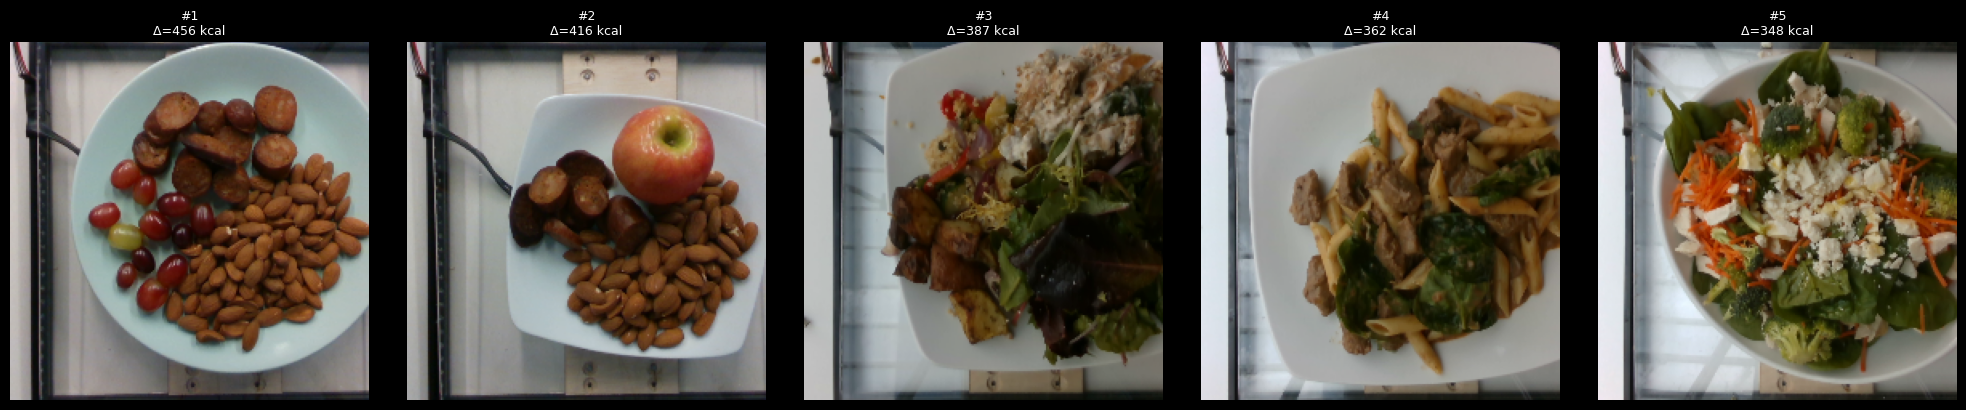

   mass_g                                        ingredients  calories_true  \
0   277.0                           almonds, sausage, grapes    1050.511108   
1   334.0                       sausage, deprecated, almonds    1013.337036   
2   658.0  shallots, olive oil, garlic, lemon juice, basi...     920.120422   
3   545.0  cream, mushroom, spinach ( raw ), olive oil, p...     950.395081   
4   416.0  carrot, goat cheese, olive oil, broccoli, spin...     902.200012   

   calories_pred   abs_error  rel_error_pct  
0     594.107117  456.403992      43.445900  
1     597.324036  416.013000      41.053764  
2     533.098450  387.021973      42.062099  
3     588.102966  362.292114      38.120159  
4     554.360352  347.839661      38.554607  


In [7]:
# 5 худших блюд
worst_5_data = get_worst_predictions(model, config, device, top_k=5)
print(worst_5_data)

**Вывод:**

Средняя калорийность в датасете = 255, а средняя масса = 214.

Как видно из топ-5 самых неудачных блюд их калорийность является особенно высокой (~1000). Модель мало обучалась на подобных блюдах и потому выдаёт особенно высокую ошибку на них. Масса у этих блюд также отличается от среднего, но не столь значительно как каларийность.